# OVMI Paper Experiments

This notebook reproduces the experiments associated with the OVMI paper. To avoid fine-tuning MEG-XL within this repository, we will download the validation and test set predictions from a model already fine-tuned on the LibriBrain brain-to-text dataset.

## Download prediction data from MEG-XL fine-tuned on LibriBrain

In [21]:
from __future__ import annotations

import importlib.util
import subprocess
import sys
from pathlib import Path
from typing import Optional


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "ovmi").exists():
            return candidate
    raise FileNotFoundError("Could not find the OVMI project root from the current directory.")


ensure_package("huggingface_hub")

from huggingface_hub import snapshot_download


DATASET_REPO_ID = "pnpl/ovmi-predictions"
PROJECT_ROOT = find_project_root()
PREDICTIONS_DIR = PROJECT_ROOT / "experiments" / "data" / "ovmi-predictions"

PREDICTIONS_DIR

PosixPath('/Users/hans/OVMI/experiments/data/ovmi-predictions')

In [22]:
snapshot_path = Path(
    snapshot_download(
        repo_id=DATASET_REPO_ID,
        repo_type="dataset",
        local_dir=PREDICTIONS_DIR,
    )
)

snapshot_path

Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 2957.33it/s]


PosixPath('/Users/hans/OVMI/experiments/data/ovmi-predictions')

In [23]:
seed_dirs = sorted(
    path
    for path in snapshot_path.iterdir()
    if path.is_dir() and not path.name.startswith(".")
)

if len(seed_dirs) != 5:
    raise ValueError(
        f"Expected 5 seed folders in {snapshot_path}, found {len(seed_dirs)}: "
        f"{[path.name for path in seed_dirs]}"
    )

for seed_dir in seed_dirs:
    file_count = sum(1 for path in seed_dir.rglob("*") if path.is_file())
    print(f"{seed_dir.name}: {file_count:,} files")

49uy26vz: 4 files
gewwn2c4: 4 files
sol1ju5n: 4 files
x7zunrsn: 4 files
x81secvn: 4 files


## Compare vocabularies selected by frequency w.r.t. Wolpaw, In-Vocab MI (Speier), and OVMI

In [24]:
ensure_package("matplotlib")

from collections import defaultdict
from pathlib import Path
import sys
from typing import Optional

from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
})


SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ovmi import load_subtlex_uk


SUBTLEX_REFERENCE = load_subtlex_uk(cache_dir=PROJECT_ROOT / "experiments" / "data" / "cache")


def subtlex_frequencies_for_vocab(vocab_words: np.ndarray) -> np.ndarray:
    return np.array([SUBTLEX_REFERENCE.get(str(word), 0.0) for word in vocab_words], dtype=np.float64)


def load_prediction_run(run_dir: Path, split: str = "test") -> dict[str, np.ndarray]:
    """Load one seed/run from the downloaded Hugging Face snapshot."""
    with np.load(run_dir / f"{split}_predictions_best.npz", allow_pickle=True) as predictions:
        subject = predictions["subject"].astype(str)
        target_word = predictions["target_word"].astype(str)
        pred_embedding = predictions["pred_embedding"].astype(np.float64)
        sentence_idx_of_word = predictions["sentence_idx_of_word"].astype(np.int64)
    with np.load(run_dir / "vocab_embeddings.npz", allow_pickle=True) as vocab:
        vocab_words = vocab["word"].astype(str)
        vocab_embeddings = vocab["t5_embedding"].astype(np.float64)
    with np.load(run_dir / "vocab_metadata.npz", allow_pickle=True) as metadata:
        word_frequency = metadata["word_frequency"].astype(np.float64)

    return {
        "subject": subject,
        "target_word": target_word,
        "pred_embedding": pred_embedding,
        "sentence_idx_of_word": sentence_idx_of_word,
        "vocab_words": vocab_words,
        "vocab_embeddings": vocab_embeddings,
        "word_frequency": word_frequency,
    }


def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, 1e-12)

In [25]:
def wolpaw_bits(correct_probability: float, vocab_size: int) -> float:
    if vocab_size <= 1:
        return 0.0
    if correct_probability <= 0.0:
        return float(np.log2(vocab_size) + np.log2(1.0 / (vocab_size - 1)))
    if correct_probability >= 1.0:
        return float(np.log2(vocab_size))
    return float(
        np.log2(vocab_size)
        + correct_probability * np.log2(correct_probability)
        + (1.0 - correct_probability)
        * np.log2((1.0 - correct_probability) / (vocab_size - 1))
    )


def in_vocab_mi(correct_probability: float, word_probabilities: np.ndarray) -> float:
    """Speier-style MI inside the selected vocabulary."""
    vocab_size = len(word_probabilities)
    if vocab_size <= 1 or correct_probability <= 0.0:
        return 0.0
    if correct_probability >= 1.0:
        positive = word_probabilities > 0
        return float(-np.sum(word_probabilities[positive] * np.log2(word_probabilities[positive])))

    output_probabilities = (
        correct_probability * word_probabilities
        + (1.0 - correct_probability) * (1.0 - word_probabilities) / (vocab_size - 1)
    )
    positive = output_probabilities > 0
    output_entropy = -np.sum(output_probabilities[positive] * np.log2(output_probabilities[positive]))
    conditional_entropy = -(
        correct_probability * np.log2(correct_probability)
        + (1.0 - correct_probability) * np.log2((1.0 - correct_probability) / (vocab_size - 1))
    )
    return float(max(0.0, output_entropy - conditional_entropy))


def subset_accuracies(
    selected: np.ndarray,
    similarity: np.ndarray,
    rows_by_word: dict[int, np.ndarray],
    instance_labels: np.ndarray,
) -> np.ndarray:
    """Decode selected words against selected retrieval targets."""
    rows = np.concatenate([rows_by_word[int(i)] for i in selected if int(i) in rows_by_word])
    local_to_selected = np.full(similarity.shape[1], -1, dtype=np.int64)
    local_to_selected[selected] = np.arange(len(selected))

    true = local_to_selected[instance_labels[rows]]
    predicted = similarity[np.ix_(rows, selected)].argmax(axis=1)

    correct = np.zeros(len(selected), dtype=np.float64)
    total = np.zeros(len(selected), dtype=np.float64)
    np.add.at(total, true, 1)
    np.add.at(correct, true, predicted == true)
    return np.divide(correct, total, out=np.zeros_like(correct), where=total > 0)

In [26]:
def compute_three_metric_traces(
    run_dir: Path,
    max_vocab: Optional[int] = None,
    min_word_instances: int = 5,
) -> dict[str, np.ndarray]:
    data = load_prediction_run(run_dir)
    vocab_words = data["vocab_words"]
    word_to_vocab_index = {word: i for i, word in enumerate(vocab_words)}

    instances_by_word = defaultdict(list)
    for word, embedding in zip(data["target_word"], data["pred_embedding"]):
        instances_by_word[word].append(embedding)

    eligible_words = [
        word
        for word, embeddings in instances_by_word.items()
        if word in word_to_vocab_index and len(embeddings) >= min_word_instances
    ]
    if not eligible_words:
        raise ValueError(f"No words in {run_dir} have at least {min_word_instances} instances.")

    test_indices = np.array(
        sorted(word_to_vocab_index[word] for word in eligible_words),
        dtype=np.int64,
    )

    instance_chunks = []
    instance_labels = []
    rows_by_word = {}
    row_start = 0
    for local_index, vocab_index in enumerate(test_indices):
        word_instances = np.stack(instances_by_word[vocab_words[vocab_index]])
        row_stop = row_start + len(word_instances)
        rows_by_word[local_index] = np.arange(row_start, row_stop)
        instance_chunks.append(word_instances)
        instance_labels.extend([local_index] * len(word_instances))
        row_start = row_stop

    all_instances = np.concatenate(instance_chunks)
    instance_labels = np.array(instance_labels, dtype=np.int64)
    retrieval_embeddings = data["vocab_embeddings"][test_indices]

    with np.errstate(all="ignore"):
        similarity = normalize_rows(all_instances) @ normalize_rows(retrieval_embeddings).T

    frequencies = subtlex_frequencies_for_vocab(data["vocab_words"])
    total_frequency = frequencies.sum()
    order = np.argsort(frequencies[test_indices])[::-1]
    if max_vocab is not None:
        order = order[:max_vocab]

    selected = []
    traces = {"wolpaw": [], "speier": [], "ovmi": [], "coverage": []}
    for local_index in order:
        selected.append(int(local_index))
        selected_array = np.array(selected, dtype=np.int64)
        selected_frequencies = frequencies[test_indices[selected_array]]
        coverage = selected_frequencies.sum() / total_frequency

        if len(selected) <= 1 or selected_frequencies.sum() == 0:
            wolpaw = speier = ovmi_score = 0.0
        else:
            per_word_accuracy = subset_accuracies(selected_array, similarity, rows_by_word, instance_labels)
            correct_probability = float(per_word_accuracy.mean())
            word_probabilities = selected_frequencies / selected_frequencies.sum()
            wolpaw = wolpaw_bits(correct_probability, len(selected))
            speier = in_vocab_mi(correct_probability, word_probabilities)
            ovmi_score = coverage * speier

        traces["wolpaw"].append(wolpaw)
        traces["speier"].append(speier)
        traces["ovmi"].append(ovmi_score)
        traces["coverage"].append(coverage)

    return {name: np.array(values, dtype=np.float64) for name, values in traces.items()}

In [27]:
MAX_VOCAB = 110
MIN_WORD_INSTANCES = 1

run_results = {}
peak_rows = []
for seed_dir in seed_dirs:
    traces = compute_three_metric_traces(
        seed_dir,
        max_vocab=MAX_VOCAB,
        min_word_instances=MIN_WORD_INSTANCES,
    )
    run_results[seed_dir.name] = traces

    for metric in ["wolpaw", "speier", "ovmi"]:
        peak_index = int(np.nanargmax(traces[metric]))
        peak_rows.append({
            "seed": seed_dir.name,
            "metric": metric,
            "peak_bits": traces[metric][peak_index],
            "peak_vocab_size": peak_index + 1,
        })

peak_table = pd.DataFrame(peak_rows)
peak_table

,seed,metric,peak_bits,peak_vocab_size
0,49uy26vz,wolpaw,0.751076,5
1,49uy26vz,speier,0.717813,5
2,49uy26vz,ovmi,0.154601,30
3,gewwn2c4,wolpaw,0.636754,5
4,gewwn2c4,speier,0.608627,5
5,gewwn2c4,ovmi,0.137882,30
6,sol1ju5n,wolpaw,0.538851,5
7,sol1ju5n,speier,0.515149,5
8,sol1ju5n,ovmi,0.159747,29
9,x7zunrsn,wolpaw,0.639830,5


In [28]:
def stack_metric(metric: str) -> np.ndarray:
    traces = [result[metric] for result in run_results.values()]
    max_length = max(len(trace) for trace in traces)
    stacked = np.full((len(traces), max_length), np.nan)
    for row, trace in enumerate(traces):
        stacked[row, : len(trace)] = trace
    return stacked


summary = {}
for metric in ["wolpaw", "speier", "ovmi", "coverage"]:
    stacked = stack_metric(metric)
    n = np.sum(~np.isnan(stacked), axis=0)
    summary[metric] = {
        "mean": np.nanmean(stacked, axis=0),
        "se": np.nanstd(stacked, axis=0, ddof=1) / np.sqrt(n),
    }

mean_peak_rows = []
for metric in ["wolpaw", "speier", "ovmi"]:
    peak_index = int(np.nanargmax(summary[metric]["mean"]))
    mean_peak_rows.append({
        "metric": metric,
        "mean_peak_bits": summary[metric]["mean"][peak_index],
        "peak_vocab_size": peak_index + 1,
    })

pd.DataFrame(mean_peak_rows)

,metric,mean_peak_bits,peak_vocab_size
0,wolpaw,0.640654,5
1,speier,0.612357,5
2,ovmi,0.155999,30


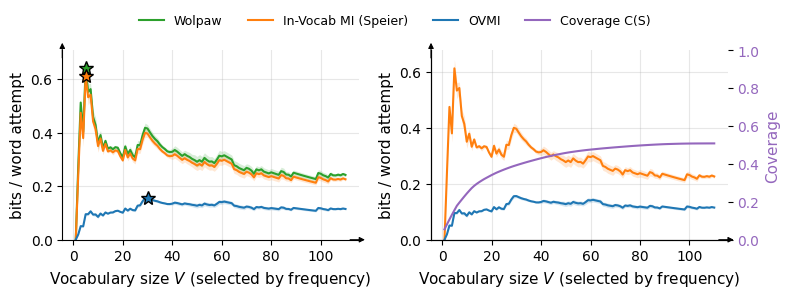

In [29]:
colors = {
    "wolpaw": "#2ca02c",
    "speier": "#ff7f0e",
    "ovmi": "#1f77b4",
    "coverage": "#9467bd",
}
labels = {
    "wolpaw": "Wolpaw",
    "speier": "In-Vocab MI (Speier)",
    "ovmi": "OVMI",
    "coverage": "Coverage C(S)",
}


def plot_mean_with_se(axis, sizes, metric, linewidth=1.5, alpha=0.18):
    mean = summary[metric]["mean"]
    se = summary[metric]["se"]
    axis.plot(sizes, mean, "-", color=colors[metric], linewidth=linewidth, label=labels[metric])
    axis.fill_between(sizes, mean - se, mean + se, color=colors[metric], alpha=alpha, linewidth=0)


def style_arrow_axes(axis):
    """Match the arrowed-axis styling used in the original plotting script."""
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    arrowprops = {
        "arrowstyle": "-|>",
        "color": "black",
        "linewidth": 0.8,
        "mutation_scale": 8,
        "shrinkA": 0,
        "shrinkB": 0,
    }
    axis.annotate(
        "",
        xy=(1.02, 0),
        xytext=(0.97, 0),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=arrowprops,
        clip_on=False,
    )
    axis.annotate(
        "",
        xy=(0, 1.04),
        xytext=(0, 0.96),
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=arrowprops,
        clip_on=False,
    )


sizes = np.arange(1, len(summary["ovmi"]["mean"]) + 1)
fig, (ax_metrics, ax_decomposition) = plt.subplots(1, 2, figsize=(8, 3))

for metric in ["wolpaw", "speier", "ovmi"]:
    plot_mean_with_se(ax_metrics, sizes, metric)
    peak_index = int(np.nanargmax(summary[metric]["mean"]))
    ax_metrics.plot(
        sizes[peak_index],
        summary[metric]["mean"][peak_index],
        "*",
        color=colors[metric],
        markeredgecolor="black",
        markersize=10,
        zorder=5,
    )

ax_metrics.set_xlabel(r"Vocabulary size $V$ (selected by frequency)")
ax_metrics.set_ylabel("bits / word attempt")
ax_metrics.set_ylim(bottom=0)
ax_metrics.grid(axis="y", alpha=0.3)
ax_metrics.grid(axis="x", alpha=0.3)
style_arrow_axes(ax_metrics)

for metric in ["speier", "ovmi"]:
    plot_mean_with_se(ax_decomposition, sizes, metric)
ax_decomposition.set_xlabel(r"Vocabulary size $V$ (selected by frequency)")
ax_decomposition.set_ylabel("bits / word attempt")
ax_decomposition.set_ylim(bottom=0)
ax_decomposition.grid(axis="y", alpha=0.3)
ax_decomposition.grid(axis="x", alpha=0.3)
style_arrow_axes(ax_decomposition)

ax_coverage = ax_decomposition.twinx()
plot_mean_with_se(ax_coverage, sizes, "coverage")
ax_coverage.set_ylabel("Coverage", color=colors["coverage"])
ax_coverage.tick_params(axis="y", labelcolor=colors["coverage"])
ax_coverage.set_ylim(0, 1)
ax_coverage.spines["top"].set_visible(False)
ax_coverage.spines["right"].set_visible(False)

legend_handles = [
    Line2D([], [], color=colors["wolpaw"], linewidth=1.5),
    Line2D([], [], color=colors["speier"], linewidth=1.5),
    Line2D([], [], color=colors["ovmi"], linewidth=1.5),
    Line2D([], [], color=colors["coverage"], linewidth=1.5),
]
legend_labels = [labels["wolpaw"], labels["speier"], labels["ovmi"], labels["coverage"]]
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Greedy vocabulary selection with OVMI improves information transfer

In [ ]:
def group_instances(words: np.ndarray, embeddings: np.ndarray) -> dict[str, np.ndarray]:
    grouped = defaultdict(list)
    for word, embedding in zip(words, embeddings):
        grouped[str(word)].append(embedding)
    return {word: np.stack(values) for word, values in grouped.items()}


def split_frequency(vocab_words: np.ndarray, instances_by_word: dict[str, np.ndarray]) -> np.ndarray:
    word_to_index = {word: i for i, word in enumerate(vocab_words)}
    frequency = np.zeros(len(vocab_words), dtype=np.float64)
    for word, instances in instances_by_word.items():
        if word in word_to_index:
            frequency[word_to_index[word]] = len(instances)
    return frequency


def prepare_split(data: dict[str, np.ndarray], test_indices: np.ndarray) -> dict[str, object]:
    instances_by_word = group_instances(data["target_word"], data["pred_embedding"])
    vocab_words = data["vocab_words"]

    chunks = []
    labels = []
    rows_by_word = {}
    row_start = 0
    for local_index, vocab_index in enumerate(test_indices):
        word_instances = instances_by_word[vocab_words[vocab_index]]
        row_stop = row_start + len(word_instances)
        rows_by_word[local_index] = np.arange(row_start, row_stop)
        chunks.append(word_instances)
        labels.extend([local_index] * len(word_instances))
        row_start = row_stop

    all_instances = np.concatenate(chunks).astype(np.float64)
    retrieval = data["vocab_embeddings"][test_indices].astype(np.float64)
    with np.errstate(all="ignore"):
        similarity = normalize_rows(all_instances) @ normalize_rows(retrieval).T

    return {
        "similarity": similarity,
        "rows_by_word": rows_by_word,
        "labels": np.array(labels, dtype=np.int64),
        "instances_by_word": instances_by_word,
    }


def ovmi_for_subset(
    selected,
    split: dict[str, object],
    reference_frequency: np.ndarray,
    test_indices: np.ndarray,
) -> float:
    selected = np.array(selected, dtype=np.int64)
    if len(selected) <= 1:
        return 0.0

    selected_frequency = reference_frequency[test_indices[selected]]
    if selected_frequency.sum() <= 0:
        return 0.0

    accuracies = subset_accuracies(
        selected,
        split["similarity"],
        split["rows_by_word"],
        split["labels"],
    )
    coverage = selected_frequency.sum() / reference_frequency.sum()
    word_probabilities = selected_frequency / selected_frequency.sum()
    return coverage * in_vocab_mi(float(accuracies.mean()), word_probabilities)


def trace_from_order(order, split, reference_frequency, test_indices):
    selected = []
    trace = []
    for local_index in order:
        selected.append(int(local_index))
        trace.append(ovmi_for_subset(selected, split, reference_frequency, test_indices))
    return np.array(trace, dtype=np.float64)


def greedy_order_on_validation(val_split, reference_frequency, test_indices, max_vocab=None, min_examples: int = 1):
    eligible = [
        local_index
        for local_index, vocab_index in enumerate(test_indices)
        if reference_frequency[vocab_index] > 0
        and len(val_split["rows_by_word"].get(local_index, [])) >= min_examples
    ]
    n_steps = min(len(eligible), max_vocab) if max_vocab is not None else len(eligible)

    selected = []
    trace = []
    for _ in range(n_steps):
        remaining = [i for i in eligible if i not in selected]
        scores = [
            ovmi_for_subset(selected + [candidate], val_split, reference_frequency, test_indices)
            for candidate in remaining
        ]
        best_candidate = remaining[int(np.argmax(scores))]
        selected.append(best_candidate)
        trace.append(max(scores))

    return selected, np.array(trace, dtype=np.float64)

In [ ]:
def compute_greedy_run(seed_dir: Path, max_vocab: int = 110, min_word_instances: int = 5, seed: int = 42):
    val_data = load_prediction_run(seed_dir, split="val")
    test_data = load_prediction_run(seed_dir, split="test")
    vocab_words = test_data["vocab_words"]
    word_to_index = {word: i for i, word in enumerate(vocab_words)}

    val_instances = group_instances(val_data["target_word"], val_data["pred_embedding"])
    test_instances = group_instances(test_data["target_word"], test_data["pred_embedding"])
    shared_words = [
        word
        for word in val_instances
        if word in test_instances
        and word in word_to_index
    ]
    test_indices = np.array(sorted(word_to_index[word] for word in shared_words), dtype=np.int64)

    val_split = prepare_split(val_data, test_indices)
    test_split = prepare_split(test_data, test_indices)
    subtlex_frequency = subtlex_frequencies_for_vocab(vocab_words)
    val_frequency = split_frequency(vocab_words, val_instances)
    test_frequency = split_frequency(vocab_words, test_instances)

    subtlex_greedy_order, val_subtlex_greedy_trace = greedy_order_on_validation(
        val_split,
        subtlex_frequency,
        test_indices,
        max_vocab=max_vocab,
        min_examples=min_word_instances,
    )
    val_greedy_order, val_greedy_trace = greedy_order_on_validation(
        val_split,
        val_frequency,
        test_indices,
        max_vocab=max_vocab,
        min_examples=min_word_instances,
    )
    peak_v = int(np.nanargmax(val_subtlex_greedy_trace)) + 1

    subtlex_order = np.argsort(subtlex_frequency[test_indices])[::-1][:max_vocab].tolist()
    val_frequency_order = np.argsort(val_frequency[test_indices])[::-1][:max_vocab].tolist()
    full_val_accuracy = subset_accuracies(
        np.arange(len(test_indices), dtype=np.int64),
        val_split["similarity"],
        val_split["rows_by_word"],
        val_split["labels"],
    )
    validation_eligible = [
        local_index
        for local_index in range(len(test_indices))
        if len(val_split["rows_by_word"].get(local_index, [])) >= min_word_instances
    ]
    best_accuracy_order = sorted(
        validation_eligible,
        key=lambda i: (-float(full_val_accuracy[i]), int(i)),
    )[:max_vocab]
    best_accuracy_x_frequency_order = sorted(
        [i for i in validation_eligible if val_frequency[test_indices[i]] > 0],
        key=lambda i: (-float(full_val_accuracy[i] * val_frequency[test_indices[i]]), int(i)),
    )[:max_vocab]
    random_order = np.random.default_rng(seed).permutation(len(test_indices))[:max_vocab].tolist()

    result = {
        "seed": seed_dir.name,
        "test_indices": test_indices,
        "test_words": np.array([vocab_words[i] for i in test_indices]),
        "subtlex_frequency": subtlex_frequency,
        "val_frequency": val_frequency,
        "test_frequency": test_frequency,
        "subtlex_greedy_order": np.array(subtlex_greedy_order, dtype=np.int64),
        "val_greedy_order": np.array(val_greedy_order, dtype=np.int64),
        "test_freq_order": np.array(subtlex_order, dtype=np.int64),
        "test_valfreq_order": np.array(val_frequency_order, dtype=np.int64),
        "test_maxpc_order": np.array(best_accuracy_order, dtype=np.int64),
        "test_maxpcfreq_order": np.array(best_accuracy_x_frequency_order, dtype=np.int64),
        "test_rand_order": np.array(random_order, dtype=np.int64),
        "val_subtlex_greedy_trace": val_subtlex_greedy_trace,
        "val_greedy_trace": val_greedy_trace,
        "test_subtlex_greedy_trace": trace_from_order(subtlex_greedy_order, test_split, subtlex_frequency, test_indices),
        "test_greedy_trace": trace_from_order(val_greedy_order, test_split, subtlex_frequency, test_indices),
        "test_freq_trace": trace_from_order(subtlex_order, test_split, subtlex_frequency, test_indices),
        "test_valfreq_trace": trace_from_order(val_frequency_order, test_split, subtlex_frequency, test_indices),
        "test_maxpc_trace": trace_from_order(best_accuracy_order, test_split, subtlex_frequency, test_indices),
        "test_maxpcfreq_trace": trace_from_order(best_accuracy_x_frequency_order, test_split, subtlex_frequency, test_indices),
        "test_rand_trace": trace_from_order(random_order, test_split, subtlex_frequency, test_indices),
        "testp_subtlex_greedy_trace": trace_from_order(subtlex_greedy_order, test_split, test_frequency, test_indices),
        "testp_greedy_trace": trace_from_order(val_greedy_order, test_split, test_frequency, test_indices),
        "testp_freq_trace": trace_from_order(subtlex_order, test_split, test_frequency, test_indices),
        "testp_valfreq_trace": trace_from_order(val_frequency_order, test_split, test_frequency, test_indices),
        "testp_maxpc_trace": trace_from_order(best_accuracy_order, test_split, test_frequency, test_indices),
        "testp_maxpcfreq_trace": trace_from_order(best_accuracy_x_frequency_order, test_split, test_frequency, test_indices),
        "testp_rand_trace": trace_from_order(random_order, test_split, test_frequency, test_indices),
        "peak_v": peak_v,
    }

    for name, order in [
        ("subtlex_greedy", subtlex_greedy_order),
        ("greedy", val_greedy_order),
        ("freq", subtlex_order),
        ("valfreq", val_frequency_order),
        ("maxpc", best_accuracy_order),
        ("maxpcfreq", best_accuracy_x_frequency_order),
    ]:
        result[f"test_{name}_peak_accs"] = subset_accuracies(
            np.array(order[:peak_v], dtype=np.int64),
            test_split["similarity"],
            test_split["rows_by_word"],
            test_split["labels"],
        )

    return result


GREEDY_MAX_VOCAB = 110
GREEDY_MIN_WORD_INSTANCES = 5

greedy_run_results = []
greedy_peak_rows = []
for seed_dir in seed_dirs:
    result = compute_greedy_run(
        seed_dir,
        max_vocab=GREEDY_MAX_VOCAB,
        min_word_instances=GREEDY_MIN_WORD_INSTANCES,
    )
    greedy_run_results.append(result)
    for label, key in [
        ("val greedy, p=SUBTLEX", "val_subtlex_greedy_trace"),
        ("val greedy, p=validation", "val_greedy_trace"),
        ("test greedy, p=SUBTLEX", "test_subtlex_greedy_trace"),
        ("test greedy, p=validation", "test_greedy_trace"),
        ("test SUBTLEX-frequency", "test_freq_trace"),
        ("test val-frequency", "test_valfreq_trace"),
        ("test best accuracy", "test_maxpc_trace"),
        ("test best accuracy x frequency", "test_maxpcfreq_trace"),
    ]:
        peak_index = int(np.nanargmax(result[key]))
        greedy_peak_rows.append({
            "seed": result["seed"],
            "trace": label,
            "peak_ovmi": result[key][peak_index],
            "peak_vocab_size": peak_index + 1,
            "val_selected_peak_v": result["peak_v"],
        })

pd.DataFrame(greedy_peak_rows)

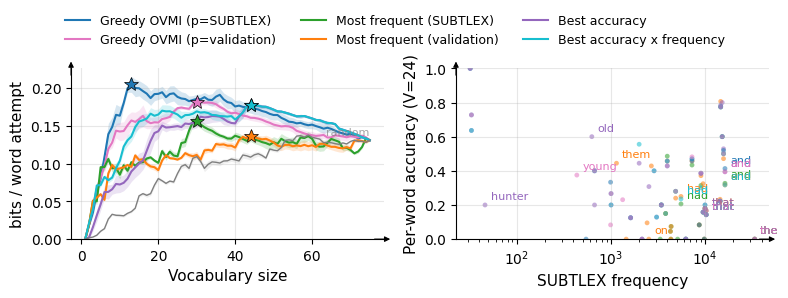

In [69]:
GREEDY_COLORS = {
    "greedy": "#e377c2",
    "subtlex_greedy": "#1f77b4",
    "subtlex": "#2ca02c",
    "valfreq": "#ff7f0e",
    "maxpc": "#9467bd",
    "maxpcfreq": "#17becf",
    "random": "#7f7f7f",
}


def plot_line_with_optional_se(axis, x, mean, se, color, label, n_runs, linewidth=1.5, alpha=0.18):
    axis.plot(x, mean, "-", color=color, linewidth=linewidth, label=label)
    if n_runs > 1:
        axis.fill_between(x, mean - se, mean + se, color=color, alpha=alpha, linewidth=0)


def style_arrow_axes(axis):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    arrowprops = {
        "arrowstyle": "-|>",
        "color": "black",
        "linewidth": 0.8,
        "mutation_scale": 8,
        "shrinkA": 0,
        "shrinkB": 0,
    }
    axis.annotate("", xy=(1.02, 0), xytext=(0.97, 0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=arrowprops, clip_on=False)
    axis.annotate("", xy=(0, 1.04), xytext=(0, 0.96), xycoords="axes fraction", textcoords="axes fraction", arrowprops=arrowprops, clip_on=False)


def stack_greedy_trace(key: str) -> np.ndarray:
    traces = [result[key] for result in greedy_run_results]
    max_length = max(len(trace) for trace in traces)
    stacked = np.full((len(traces), max_length), np.nan)
    for row, trace in enumerate(traces):
        stacked[row, : len(trace)] = trace
    return stacked


greedy_summary = {}
for key in [
    "test_subtlex_greedy_trace",
    "test_greedy_trace",
    "test_freq_trace",
    "test_valfreq_trace",
    "test_maxpc_trace",
    "test_maxpcfreq_trace",
    "test_rand_trace",
    "testp_subtlex_greedy_trace",
    "testp_greedy_trace",
    "testp_freq_trace",
    "testp_valfreq_trace",
    "testp_maxpc_trace",
    "testp_maxpcfreq_trace",
    "testp_rand_trace",
]:
    stacked = stack_greedy_trace(key)
    n = np.sum(~np.isnan(stacked), axis=0)
    greedy_summary[key] = {
        "mean": np.nanmean(stacked, axis=0),
        "se": np.nanstd(stacked, axis=0, ddof=1) / np.sqrt(n),
    }


def annotate_trace_end(axis, values, label, color, x_values=None, alpha=0.75):
    finite = np.where(np.isfinite(values))[0]
    if len(finite) == 0:
        return
    index = int(finite[-1])
    x = x_values[index] if x_values is not None else index + 1
    axis.annotate(label, (x, values[index]), xytext=(0, 2), textcoords="offset points", ha="right", va="bottom", fontsize=8, color=color, alpha=alpha)


def pick_annotated_words(points, n=12, seed=0):
    unique = {word: frequency for word, frequency, _accuracy, _color in points if frequency > 0}
    words = list(unique)
    if not words:
        return set()
    log_frequency = np.log([unique[word] for word in words])
    edges = np.linspace(log_frequency.min(), log_frequency.max(), n + 1)
    rng = np.random.default_rng(seed)
    chosen = set()
    for i in range(n):
        if i == n - 1:
            in_bin = (log_frequency >= edges[i]) & (log_frequency <= edges[i + 1])
        else:
            in_bin = (log_frequency >= edges[i]) & (log_frequency < edges[i + 1])
        indices = np.where(in_bin)[0]
        if len(indices):
            chosen.add(words[int(rng.choice(indices))])
    return chosen


TRACE_SPECS = [
    ("subtlex_greedy_trace", GREEDY_COLORS["subtlex_greedy"], "Greedy OVMI (p=SUBTLEX)"),
    ("greedy_trace", GREEDY_COLORS["greedy"], "Greedy OVMI (p=validation)"),
    ("freq_trace", GREEDY_COLORS["subtlex"], "Most frequent (SUBTLEX)"),
    ("valfreq_trace", GREEDY_COLORS["valfreq"], "Most frequent (validation)"),
    ("maxpc_trace", GREEDY_COLORS["maxpc"], "Best accuracy"),
    ("maxpcfreq_trace", GREEDY_COLORS["maxpcfreq"], "Best accuracy x frequency"),
]
SCATTER_SPECS = [
    ("test_freq_order", "test_freq_peak_accs", GREEDY_COLORS["subtlex"]),
    ("test_valfreq_order", "test_valfreq_peak_accs", GREEDY_COLORS["valfreq"]),
    ("test_maxpc_order", "test_maxpc_peak_accs", GREEDY_COLORS["maxpc"]),
    ("test_maxpcfreq_order", "test_maxpcfreq_peak_accs", GREEDY_COLORS["maxpcfreq"]),
    ("subtlex_greedy_order", "test_subtlex_greedy_peak_accs", GREEDY_COLORS["subtlex_greedy"]),
    ("val_greedy_order", "test_greedy_peak_accs", GREEDY_COLORS["greedy"]),
]


def plot_greedy_summary(trace_prefix: str, random_key: str, scatter_frequency_key: str, scatter_xlabel: str):
    sizes = np.arange(1, len(greedy_summary[f"{trace_prefix}subtlex_greedy_trace"]["mean"]) + 1)
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 3))

    for suffix, color, label in TRACE_SPECS:
        key = f"{trace_prefix}{suffix}"
        plot_line_with_optional_se(ax_left, sizes, greedy_summary[key]["mean"], greedy_summary[key]["se"], color, label, len(greedy_run_results))
        peak_index = int(np.nanargmax(greedy_summary[key]["mean"]))
        ax_left.plot(peak_index + 1, greedy_summary[key]["mean"][peak_index], "*", color=color, markersize=10, markeredgecolor="black", markeredgewidth=0.5, zorder=5)

    plot_line_with_optional_se(ax_left, sizes, greedy_summary[random_key]["mean"], greedy_summary[random_key]["se"], GREEDY_COLORS["random"], "_nolegend_", len(greedy_run_results), linewidth=1.0, alpha=0.12)
    annotate_trace_end(ax_left, greedy_summary[random_key]["mean"], "random", GREEDY_COLORS["random"], x_values=sizes, alpha=0.7)

    ax_left.set_xlabel("Vocabulary size")
    ax_left.set_ylabel("bits / word attempt")
    ax_left.set_ylim(bottom=0)
    ax_left.grid(axis="y", alpha=0.3)
    ax_left.grid(axis="x", alpha=0.3)
    style_arrow_axes(ax_left)

    reference_run = greedy_run_results[0]
    peak_v = int(reference_run["peak_v"])
    test_indices = reference_run["test_indices"]
    test_words = reference_run["test_words"]
    scatter_frequency = reference_run[scatter_frequency_key]

    points = []
    for order_key, accuracy_key, color in SCATTER_SPECS:
        local_indices = np.asarray(reference_run[order_key][:peak_v], dtype=np.int64)
        x_frequency = scatter_frequency[test_indices[local_indices]].astype(float)
        accuracies = reference_run[accuracy_key]
        ax_right.scatter(x_frequency, accuracies, s=12, color=color, alpha=0.55, edgecolors="none")
        for local_index, frequency, accuracy in zip(local_indices, x_frequency, accuracies):
            points.append((str(test_words[local_index]).strip().lower(), float(frequency), float(accuracy), color))

    annotated_words = pick_annotated_words(points)
    for word, frequency, accuracy, color in points:
        if word in annotated_words:
            ax_right.annotate(word, (frequency, accuracy), xytext=(4, 4), textcoords="offset points", fontsize=8, color=color)

    ax_right.set_xscale("log")
    ax_right.set_xlabel(scatter_xlabel)
    ax_right.set_ylabel(f"Per-word accuracy (V={peak_v})")
    ax_right.set_ylim(0, 1)
    ax_right.grid(alpha=0.3)
    style_arrow_axes(ax_right)

    handles, legend_labels = ax_left.get_legend_handles_labels()
    legend_columns = int(np.ceil(len(handles) / 2))
    fig.legend(handles, legend_labels, loc="upper center", ncol=legend_columns, bbox_to_anchor=(0.5, 1.0), frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.86])
    plt.show()


plot_greedy_summary("test_", "test_rand_trace", "subtlex_frequency", "SUBTLEX frequency")
plot_greedy_summary("testp_", "testp_rand_trace", "test_frequency", "LibriBrain test frequency")

## Downstream Improvements

### Sentence-level WER and SBERT similarity at matched test-corpus coverage

In [ ]:
ensure_package("jiwer")
ensure_package("sentence-transformers", "sentence_transformers")

from collections import Counter

import jiwer
from sentence_transformers import SentenceTransformer


SENTENCE_COVERAGES = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
SENTENCE_VOCAB_SIZES = np.arange(1, 61)
SBERT_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

In [ ]:
SENTENCE_METHODS = [
    ("subtlex_greedy", "subtlex_greedy_order", GREEDY_COLORS["subtlex_greedy"], "Greedy OVMI (p=SUBTLEX)", "o"),
    ("greedy", "val_greedy_order", GREEDY_COLORS["greedy"], "Greedy OVMI (p=validation)", "o"),
    ("freq", "test_freq_order", GREEDY_COLORS["subtlex"], "Most frequent (SUBTLEX)", "s"),
    ("valfreq", "test_valfreq_order", GREEDY_COLORS["valfreq"], "Most frequent (validation)", "s"),
    ("maxpc", "test_maxpc_order", GREEDY_COLORS["maxpc"], "Best accuracy", "P"),
    ("maxpcfreq", "test_maxpcfreq_order", GREEDY_COLORS["maxpcfreq"], "Best accuracy x frequency", "X"),
]


def plot_sentence_line_with_optional_se(axis, x, mean, se, color, label, n_runs, marker="o", linewidth=1.5, alpha=0.18, line_alpha=1.0):
    axis.plot(x, mean, "-", marker=marker, color=color, linewidth=linewidth, alpha=line_alpha, label=label)
    if n_runs > 1:
        axis.fill_between(x, mean - se, mean + se, color=color, alpha=alpha, linewidth=0)


def pick_v_for_coverage(cumulative_coverage: np.ndarray, target: float) -> tuple[int, float]:
    if len(cumulative_coverage) == 0:
        return 0, 0.0
    index = int(np.searchsorted(cumulative_coverage, target, side="left"))
    index = min(index, len(cumulative_coverage) - 1)
    return index + 1, float(cumulative_coverage[index])


def sentence_text(tokens: list[str]) -> str:
    return " ".join(str(token).lower().strip() for token in tokens if str(token).strip())


def nearest_vocab_words(pred_embeddings: np.ndarray, vocab_embeddings_subset: np.ndarray) -> np.ndarray:
    with np.errstate(all="ignore"):
        similarity = normalize_rows(pred_embeddings.astype(np.float64)) @ normalize_rows(vocab_embeddings_subset.astype(np.float64)).T
    return similarity.argmax(axis=1)


def decode_sentences_for_vocabulary(test_data: dict[str, np.ndarray], vocab_global_indices: np.ndarray) -> tuple[list[str], list[str]]:
    vocab_words = test_data["vocab_words"]
    vocab_strings = np.array([str(vocab_words[index]) for index in vocab_global_indices])
    vocab_set = set(vocab_strings.tolist())

    target_words = np.array([str(word) for word in test_data["target_word"]])
    in_vocab = np.array([word in vocab_set for word in target_words])
    predicted_words = np.array([""] * len(target_words), dtype=object)

    if in_vocab.any():
        predicted_local = nearest_vocab_words(
            test_data["pred_embedding"][in_vocab],
            test_data["vocab_embeddings"][vocab_global_indices],
        )
        predicted_words[in_vocab] = vocab_strings[predicted_local]

    sentence_groups = defaultdict(lambda: ([], []))
    for row, word in enumerate(target_words):
        key = (str(test_data["subject"][row]), int(test_data["sentence_idx_of_word"][row]))
        target_tokens, hypothesis_tokens = sentence_groups[key]
        target_tokens.append(word)
        if in_vocab[row]:
            hypothesis_tokens.append(str(predicted_words[row]))

    refs, hyps = [], []
    for target_tokens, hypothesis_tokens in sentence_groups.values():
        if hypothesis_tokens:
            refs.append(sentence_text(target_tokens))
            hyps.append(sentence_text(hypothesis_tokens))
    return refs, hyps


def score_sentences(refs: list[str], hyps: list[str]) -> dict[str, float]:
    if not refs:
        return {"wer": np.nan, "sbert_cos": np.nan}

    ref_embeddings = sbert_model.encode(refs, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True)
    hyp_embeddings = sbert_model.encode(hyps, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True)
    return {
        "wer": float(jiwer.wer(refs, hyps)),
        "sbert_cos": float(np.mean(np.sum(ref_embeddings * hyp_embeddings, axis=1))),
    }

In [ ]:
def compute_sentence_metrics_for_run(result: dict[str, object], vocab_sizes: np.ndarray) -> dict[str, object]:
    seed_dir = PREDICTIONS_DIR / result["seed"]
    test_data = load_prediction_run(seed_dir, split="test")
    test_indices = result["test_indices"]

    target_counts = Counter(test_data["target_word"].astype(str).tolist())
    token_counts = np.array(
        [target_counts.get(str(test_data["vocab_words"][global_index]), 0) for global_index in test_indices],
        dtype=np.float64,
    )
    total_tokens = len(test_data["target_word"])

    method_results = {}
    method_scores = {key: {"wer": [], "sbert_cos": []} for key, *_ in SENTENCE_METHODS}

    method_coverage = {}
    for key, order_key, *_ in SENTENCE_METHODS:
        order = np.asarray(result[order_key], dtype=np.int64)
        method_coverage[key] = np.cumsum(token_counts[order]) / total_tokens

    for vocab_size in vocab_sizes:
        for key, order_key, *_ in SENTENCE_METHODS:
            order = np.asarray(result[order_key], dtype=np.int64)
            clipped_vocab_size = min(int(vocab_size), len(order))
            vocab_global_indices = test_indices[order[:clipped_vocab_size]]
            refs, hyps = decode_sentences_for_vocabulary(test_data, vocab_global_indices)
            scores = score_sentences(refs, hyps)

            for metric in ["wer", "sbert_cos"]:
                method_scores[key][metric].append(scores[metric])

    for key, *_ in SENTENCE_METHODS:
        method_results[key] = {
            "coverage": np.array(method_coverage[key][: len(vocab_sizes)], dtype=np.float64),
            "vocab_size": np.array(vocab_sizes, dtype=np.float64),
            "wer": np.array(method_scores[key]["wer"], dtype=np.float64),
            "sbert_cos": np.array(method_scores[key]["sbert_cos"], dtype=np.float64),
        }

    return {"seed": result["seed"], "vocab_sizes": vocab_sizes, "methods": method_results}


sentence_metric_results = [
    compute_sentence_metrics_for_run(result, SENTENCE_VOCAB_SIZES)
    for result in greedy_run_results
]

In [ ]:
def stack_sentence_metric(method_key: str, field: str) -> np.ndarray:
    return np.array([
        run_result["methods"][method_key][field]
        for run_result in sentence_metric_results
    ], dtype=np.float64)


def sentence_mean_and_se(stacked: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = np.sum(~np.isnan(stacked), axis=0)
    mean = np.nanmean(stacked, axis=0)
    se = np.zeros_like(mean)
    valid = n > 1
    if np.any(valid):
        se[valid] = np.nanstd(stacked[:, valid], axis=0, ddof=1) / np.sqrt(n[valid])
    return mean, se, n


def plot_sentence_metric(metric_key: str, metric_label: str, lower_is_better: bool) -> None:
    fig, axis = plt.subplots(1, 1, figsize=(4, 3))
    n_runs = len(sentence_metric_results)

    for method_key, _order_key, color, label, marker in SENTENCE_METHODS:
        x_values = np.nanmean(stack_sentence_metric(method_key, "vocab_size"), axis=0)
        metric_values = stack_sentence_metric(method_key, metric_key)
        mean, se, _ = sentence_mean_and_se(metric_values)
        positive = mean > 0
        plot_sentence_line_with_optional_se(
            axis,
            x_values[positive],
            mean[positive],
            se[positive],
            color,
            label,
            n_runs,
            marker=marker,
        )

    suffix = " (lower is better)" if lower_is_better else ""
    axis.set_xlabel("Vocabulary size V")
    axis.set_ylabel(metric_label + suffix)
    axis.set_xlim(1, SENTENCE_VOCAB_SIZES[-1])
    axis.set_yscale("log")
    axis.grid(True, alpha=0.3)
    style_arrow_axes(axis)

    handles, labels = axis.get_legend_handles_labels()
    legend_columns = int(np.ceil(len(handles) / 2))
    fig.legend(handles, labels, loc="upper center", ncol=legend_columns, bbox_to_anchor=(0.5, 1.0), frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.86])
    plt.show()


plot_sentence_metric("wer", "WER", lower_is_better=True)
plot_sentence_metric("sbert_cos", "SBERT Cosine Similarity", lower_is_better=False)